In [1]:
import netCDF4
from netCDF4 import Dataset
import numpy as np
import numpy.ma as ma
import glob
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from datetime import timedelta
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
import matplotlib.ticker as mticker
from scipy import interpolate,stats
from scipy.interpolate import interp1d
import cartopy.crs as ccrs
import cartopy.feature as cfeat
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
state_borders = cfeat.NaturalEarthFeature(category = 'cultural', name = 'admin_1_states_provinces_lakes', scale = '50m', facecolor = 'none')
import julian
import wrf
from wrf import getvar

import csv
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import io
from urllib.request import urlopen, Request
from PIL import Image

from warnings import filterwarnings
filterwarnings(action='ignore', category=DeprecationWarning, message='`np.bool` is a deprecated alias')


In [2]:
gcas_raster = np.load('GCAS.RASTER.FLAG.2DARRAY.FILTERED.20230802.npy')
gcas_lat = np.load('GCAS.LAT.DEG.2DARRAY.FILTERED.20230802.npy')
gcas_lon = np.load('GCAS.LON.DEG.2DARRAY.FILTERED.20230802.npy')
gcas_seconds = np.load('GCAS.TIME.SECONDS.2DARRAY.FILTERED.20230802.npy')

# NO2 VCDs using GCAS with WRF-Chem AMF and a priori
gcas_no2vcd = np.load('GCAS.NO2VCD.MOLECULES.CM2.2DARRAY.FILTERED.20230802.WRFCHEM.VERSION.npy')


# NO2 VCDs using WRF-Chem with WRF-Chem AMF and a priori
mod_no2vcd = np.load('WRFCHEM.NO2VCD.MOLECULES.CM2.2DARRAY.FILTERED.20230802.HR_V2.npy')

In [3]:
gcas_lat_r1 = (np.where(gcas_raster==1,gcas_lat,np.nan))
gcas_lat_r2 = (np.where(gcas_raster==2,gcas_lat,np.nan))
gcas_lat_r3 = (np.where(gcas_raster==3,gcas_lat,np.nan))

print('LAT:')
print('R1 min/max:')
print(np.nanmin(gcas_lat_r1),np.nanmax(gcas_lat_r1))

print('R2 min/max:')
print(np.nanmin(gcas_lat_r2),np.nanmax(gcas_lat_r2))

print('R3 min/max:')
print(np.nanmin(gcas_lat_r3),np.nanmax(gcas_lat_r3))

print('')

gcas_lon_r1 = (np.where(gcas_raster==1,gcas_lon,np.nan))
gcas_lon_r2 = (np.where(gcas_raster==2,gcas_lon,np.nan))
gcas_lon_r3 = (np.where(gcas_raster==3,gcas_lon,np.nan))

print('LON:')
print('R1 min/max:')
print(np.nanmin(gcas_lon_r1),np.nanmax(gcas_lon_r1))

print('R2 min/max:')
print(np.nanmin(gcas_lon_r2),np.nanmax(gcas_lon_r2))

print('R3 min/max:')
print(np.nanmin(gcas_lon_r3),np.nanmax(gcas_lon_r3))

print('')

plot_vcd_factor = (1e15)

gcas_no2vcd_r1 = (np.where(gcas_raster==1,gcas_no2vcd,np.nan))/plot_vcd_factor
gcas_no2vcd_r2 = (np.where(gcas_raster==2,gcas_no2vcd,np.nan))/plot_vcd_factor
gcas_no2vcd_r3 = (np.where(gcas_raster==3,gcas_no2vcd,np.nan))/plot_vcd_factor

mod_no2vcd_r1 = (np.where(gcas_raster==1,mod_no2vcd,np.nan))/plot_vcd_factor
mod_no2vcd_r2 = (np.where(gcas_raster==2,mod_no2vcd,np.nan))/plot_vcd_factor
mod_no2vcd_r3 = (np.where(gcas_raster==3,mod_no2vcd,np.nan))/plot_vcd_factor

print('NO2 VCD:')
print('R1 min/max:')
print(np.nanmin(gcas_no2vcd_r1),np.nanmax(gcas_no2vcd_r1))
print(np.nanmin(mod_no2vcd_r1),np.nanmax(mod_no2vcd_r1))

print('R2 min/max:')
print(np.nanmin(gcas_no2vcd_r2),np.nanmax(gcas_no2vcd_r2))
print(np.nanmin(mod_no2vcd_r2),np.nanmax(mod_no2vcd_r2))

print('R3 min/max:')
print(np.nanmin(gcas_no2vcd_r3),np.nanmax(gcas_no2vcd_r3))
print(np.nanmin(mod_no2vcd_r3),np.nanmax(mod_no2vcd_r3))

print('')


LAT:
R1 min/max:
41.115165 42.7662425
R2 min/max:
41.1655425 42.8498425
R3 min/max:
41.139475000000004 42.761505

LON:
R1 min/max:
-88.4215425 -87.04040499999999
R2 min/max:
-88.408365 -87.12049499999999
R3 min/max:
-88.45000250000001 -87.0407375

NO2 VCD:
R1 min/max:
0.734906015547392 24.006973104062464
1.1887019205912923 14.684017218974487
R2 min/max:
0.663452188147712 22.035022621966338
0.9616949709940249 14.21369621353179
R3 min/max:
0.256312541708288 19.475423977013246
0.9865926803097151 15.735086479073503



In [4]:
gcas_seconds_r1 = (np.where(gcas_raster==1,gcas_seconds,np.nan)).flatten()
gcas_seconds_r2 = (np.where(gcas_raster==2,gcas_seconds,np.nan)).flatten()
gcas_seconds_r3 = (np.where(gcas_raster==3,gcas_seconds,np.nan)).flatten()

gcas_dt_r1 = []
gcas_dt_r2 = []
gcas_dt_r3 = []

for i in range(len(gcas_seconds_r1)):
    if ~np.isnan(gcas_seconds_r1[i]):
        gcas_dt_r1.append(dt.datetime(2023,8,2,0,0,0)+timedelta(seconds=gcas_seconds_r1[i]))

print('R1:')
print(gcas_dt_r1[0],gcas_dt_r1[-1])
print('')

for i in range(len(gcas_seconds_r2)):
    if ~np.isnan(gcas_seconds_r2[i]):
        gcas_dt_r2.append(dt.datetime(2023,8,2,0,0,0)+timedelta(seconds=gcas_seconds_r2[i]))

print('r2:')
print(gcas_dt_r2[0],gcas_dt_r2[-1])
print('')

for i in range(len(gcas_seconds_r3)):
    if ~np.isnan(gcas_seconds_r3[i]):
        gcas_dt_r3.append(dt.datetime(2023,8,2,0,0,0)+timedelta(seconds=gcas_seconds_r3[i]))

print('r3:')
print(gcas_dt_r3[0],gcas_dt_r3[-1])
print('')


R1:
2023-08-02 13:24:36.849600 2023-08-02 15:51:35.665200

r2:
2023-08-02 15:51:38.073600 2023-08-02 18:20:57.912000

r3:
2023-08-02 18:21:00.194400 2023-08-02 20:51:35.186400



In [5]:
datadir = '/ships22/raqms/jacdan/AEROMMA_ANALYSES/6.AGES.CHICAGO.PAPER/'
track_files = sorted(glob.glob(datadir+'Searey*track_mission*.nc'))

searey_lat_l1 = Dataset(track_files[0],'r').variables['lat'][:]
searey_lon_l1 = Dataset(track_files[0],'r').variables['lon'][:]
searey_lat_l2 = Dataset(track_files[1],'r').variables['lat'][:]
searey_lon_l2 = Dataset(track_files[1],'r').variables['lon'][:]
searey_lat_l3 = Dataset(track_files[2],'r').variables['lat'][:]
searey_lon_l3 = Dataset(track_files[2],'r').variables['lon'][:]

searey_utcsec_l1 = Dataset(track_files[0],'r').variables['utcsec'][:]
searey_utcsec_l2 = Dataset(track_files[1],'r').variables['utcsec'][:]
searey_utcsec_l3 = Dataset(track_files[2],'r').variables['utcsec'][:]

searey_dt_l1 = []
searey_dt_l2 = []
searey_dt_l3 = []

for i in range(len(searey_utcsec_l1)):
    if ~np.isnan(searey_utcsec_l1[i]):
        searey_dt_l1.append(dt.datetime(2023,8,2,0,0,0)+timedelta(seconds=int(searey_utcsec_l1[i])))

print('l1:')
print(searey_dt_l1[0],searey_dt_l1[-1])
print(searey_dt_l1[0]-timedelta(hours=6),searey_dt_l1[-1]-timedelta(hours=6))
print('')

for i in range(len(searey_utcsec_l2)):
    if ~np.isnan(searey_utcsec_l2[i]):
        searey_dt_l2.append(dt.datetime(2023,8,2,0,0,0)+timedelta(seconds=int(searey_utcsec_l2[i])))

print('l2:')
print(searey_dt_l2[0],searey_dt_l2[-1])
print(searey_dt_l2[0]-timedelta(hours=6),searey_dt_l2[-1]-timedelta(hours=6))
print('')

for i in range(len(searey_utcsec_l3)):
    if ~np.isnan(searey_utcsec_l3[i]):
        searey_dt_l3.append(dt.datetime(2023,8,2,0,0,0)+timedelta(seconds=int(searey_utcsec_l3[i])))

print('l3:')
print(searey_dt_l3[0],searey_dt_l3[-1])
print(searey_dt_l3[0]-timedelta(hours=6),searey_dt_l3[-1]-timedelta(hours=6))
print('')


l1:
2023-08-02 15:03:19 2023-08-02 16:44:48
2023-08-02 09:03:19 2023-08-02 10:44:48

l2:
2023-08-02 17:42:00 2023-08-02 19:23:50
2023-08-02 11:42:00 2023-08-02 13:23:50

l3:
2023-08-02 20:05:34 2023-08-02 22:54:04
2023-08-02 14:05:34 2023-08-02 16:54:04



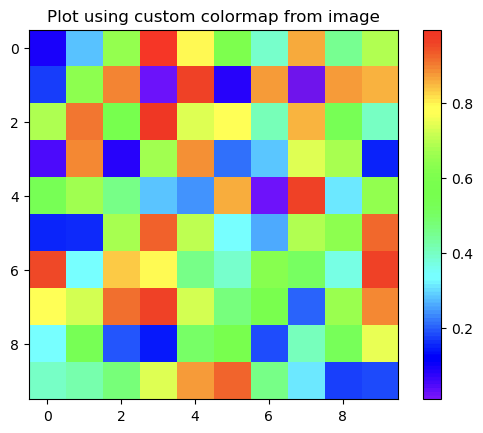

In [6]:
import matplotlib.image as mpimg
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

def create_cmap_from_colorbar_image(image_path):
    """
    Creates a Matplotlib colormap from a color bar image.

    Args:
        image_path (str): The file path to the color bar image.

    Returns:
        matplotlib.colors.LinearSegmentedColormap: The custom colormap.
    """
    # 1. Load the image
    img = mpimg.imread(image_path)
    
    # 2. Extract the relevant pixel data
    # Assuming a vertical color bar, we take the first column of pixels (index 0)
    # and all rows. The last dimension [:] gets the R, G, B, A values.
    # Adjust the column index (e.g., to a middle column if the first has a border) 
    # if necessary.
    colors_from_img = img[:, 0, :]
    
    # The number of entries in the colormap should match the number of pixels in 
    # the color bar image (the height of the image).
    N = img.shape[0]
    
    # 3. Create the LinearSegmentedColormap
    # The 'colors_from_img' is a list of colors which is used to define the map.
    custom_cmap = LinearSegmentedColormap.from_list('custom_colorbar', colors_from_img, N=N)
    
    return custom_cmap

# --- Usage Example ---
# Replace 'path/to/your/colorbar_image.png' with the actual path to your image file
image_path = '/home/jacdan/AEROMMA/6.AGES.CHICAGO/Laura.Rainbow.Colorbar.png' 

try:
    my_cmap = create_cmap_from_colorbar_image(image_path)
    
    # 4. Use the new colormap
    # Example: Display some random data using the custom colormap
    data = np.random.rand(10, 10)
    plt.imshow(data, cmap=my_cmap)
    plt.colorbar()
    plt.title("Plot using custom colormap from image")
    plt.show()

except FileNotFoundError:
    print(f"Error: Image file not found at {image_path}")
    print("Please update the 'image_path' variable to your image's location.")


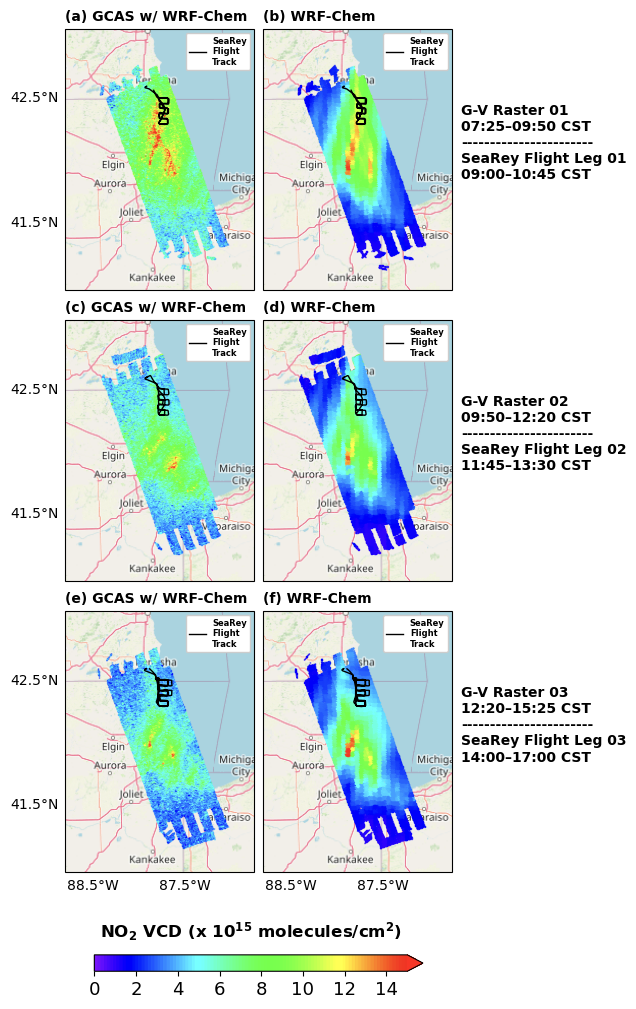

In [7]:
#0,25

#fig = plt.figure(figsize=(8, 15),constrained_layout=True)
#gs = fig.add_gridspec(3,2)

request = cimgt.OSM()
extent = [-88.8,-86.75,40.95,43.05] # GCAS bounds

fig,axes = plt.subplots(3,2,figsize=(6.25,10),subplot_kw={'projection': request.crs},layout='constrained')

row_idx = [0,0,1,1,2,2]
col_idx = [0,1,0,1,0,1]
raster_idx = ['01','01','02','02','03','03']
#raster_time = ['13:30—16:00','13:30-16:00','16:00-18:30','16:00-18:30','18:30-21:00','18:30-21:00']
raster_time = ['07:25–09:50','07:25–09:50','09:50–12:20','09:50–12:20','12:20–15:25','12:20–15:25']

plot_lat = [gcas_lat_r1,gcas_lat_r1,gcas_lat_r2,gcas_lat_r2,gcas_lat_r3,gcas_lat_r3]
plot_lon = [gcas_lon_r1,gcas_lon_r1,gcas_lon_r2,gcas_lon_r2,gcas_lon_r3,gcas_lon_r3]
plot_vcd = [gcas_no2vcd_r1,mod_no2vcd_r1,gcas_no2vcd_r2,mod_no2vcd_r2,gcas_no2vcd_r3,mod_no2vcd_r3]
plot_vmax = [15,15,15,15,15,15]

searey_lat = [searey_lat_l1,searey_lat_l1,searey_lat_l2,searey_lat_l2,searey_lat_l3,searey_lat_l3]
searey_lon = [searey_lon_l1,searey_lon_l1,searey_lon_l2,searey_lon_l2,searey_lon_l3,searey_lon_l3]
searey_time = ['09:00–10:45','09:00–10:45','11:45–13:30','11:45–13:30','14:00–17:00','14:00–17:00']

# plot_titles = ['(a) GCAS w/ WRF-Chem','(d) WRF-Chem','(b) GCAS w/ WRF-Chem','(e) WRF-Chem','(c) GCAS w/ WRF-Chem','(f) WRF-Chem'] # down columns
plot_titles = ['(a) GCAS w/ WRF-Chem','(b) WRF-Chem','(c) GCAS w/ WRF-Chem','(d) WRF-Chem','(e) GCAS w/ WRF-Chem','(f) WRF-Chem'] # across rows

for i in range(6):
    axes[row_idx[i],col_idx[i]].set_extent(extent)
    axes[row_idx[i],col_idx[i]].add_image(request,7)

    gl = axes[row_idx[i],col_idx[i]].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0, linestyle=':')
    gl.top_labels = False
    gl.right_labels = False
    if i in [1,3,5]:
        gl.left_labels = False
    if i in [0,1,2,3]:
        gl.bottom_labels = False
    gl.xlocator = mticker.FixedLocator([-88.5,-88.0,-87.5,-87.0])
    gl.ylocator = mticker.FixedLocator([41.5,42.5])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'black'}
    gl.ylabel_style = {'size': 10, 'color': 'black'}

    plot_lonlat = axes[row_idx[i],col_idx[i]].projection.transform_points(ccrs.Geodetic(), plot_lon[i].flatten(),plot_lat[i].flatten())
    b = axes[row_idx[i],col_idx[i]].scatter(plot_lonlat[:,0],plot_lonlat[:,1],c=plot_vcd[i].flatten(),vmin=0,vmax=plot_vmax[i],transform=request.crs,zorder=1001,cmap=my_cmap,s=0.02,alpha=1.0,marker='s')

    if i in [5]:
        c = fig.colorbar(b,ax=axes[:,:],orientation='horizontal',extend='max',shrink=0.85,pad=0.01)
        # Set the ticks and labels
        tick_positions = [0,2,4,6,8,10,12,14]
        tick_labels = ['0','2','4','6','8','10','12','14']
        c.set_ticks(tick_positions)
        c.set_ticklabels(tick_labels)
        c.ax.set_xlabel('\n'+r'NO$_{\rm \bf{2}}$ VCD (x 10$^{\rm \bf{15}}$ molecules/cm$^{\rm \bf{2}}$)',fontsize=12,fontweight='bold',labelpad=-70)
        c.ax.tick_params(labelsize=13)



    axes[row_idx[i],col_idx[i]].set_title(plot_titles[i],loc='left',fontweight='bold',fontsize=10)


    raster_lonlat = axes[row_idx[i],col_idx[i]].projection.transform_points(ccrs.Geodetic(),np.array([-87,-86.65]),np.array([41,41.85]))
    if i in [1,3,5]:
        axes[row_idx[i],col_idx[i]].text(raster_lonlat[1,0],raster_lonlat[1,1],'G-V Raster '+raster_idx[i]+'\n'+raster_time[i]+
                                         ' CST'+'\n-----------------------'+'\nSeaRey Flight Leg '+raster_idx[i]+'\n'+searey_time[i]+' CST',
                                         fontweight='bold',fontsize=10,transform=request.crs)

    searey_lonlat = axes[row_idx[i],col_idx[i]].projection.transform_points(ccrs.Geodetic(),searey_lon[i],searey_lat[i])
    axes[row_idx[i],col_idx[i]].plot(searey_lonlat[:,0],searey_lonlat[:,1],c='k',linewidth=1,transform=request.crs,zorder=1100,label='SeaRey\nFlight\nTrack')
    axes[row_idx[i],col_idx[i]].legend(loc='upper right',framealpha=1.0,prop={'weight':'bold','size':6})

#plt.suptitle('August 2, 2023\n',fontsize=15,fontweight='bold',x=0.425)
plt.savefig('AGES.Chicago.WRFChem.GCAS.NO2VCD.Comparison.c20260305.png',dpi=300,bbox_inches='tight')
plt.show()
